In [2]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import seaborn as sns
import numpy as np
project_root = Path().resolve().parent
sys.path.append(str(project_root))
from scripts.rq2_function_lib import plot_national_fuel_prices_year, set_plot_style, load_brent, compute_ccf_year, load_and_merge_year, build_panel_dataset

set_plot_style()

# To what extend does the oil price affect the fuel prices?
## -> Is there a lag?

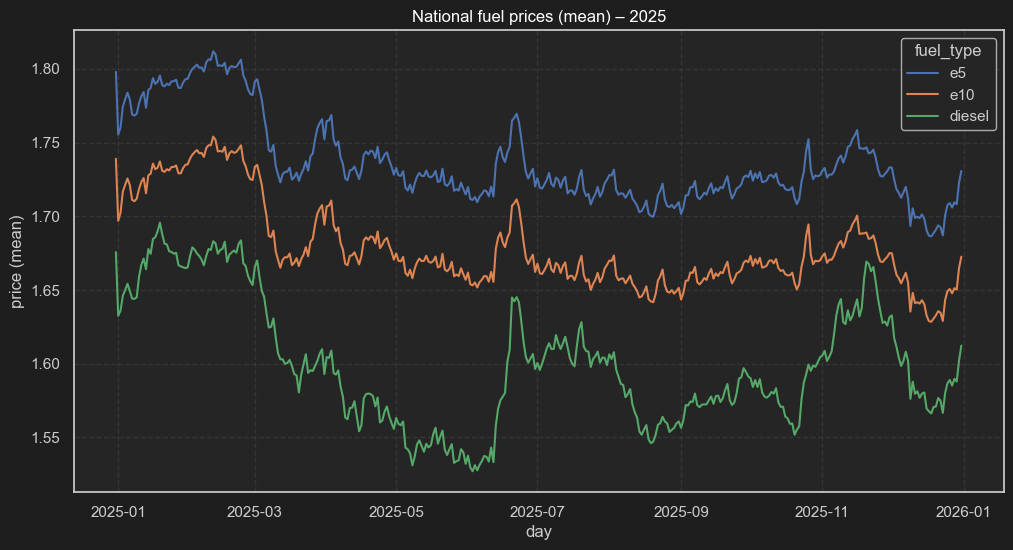

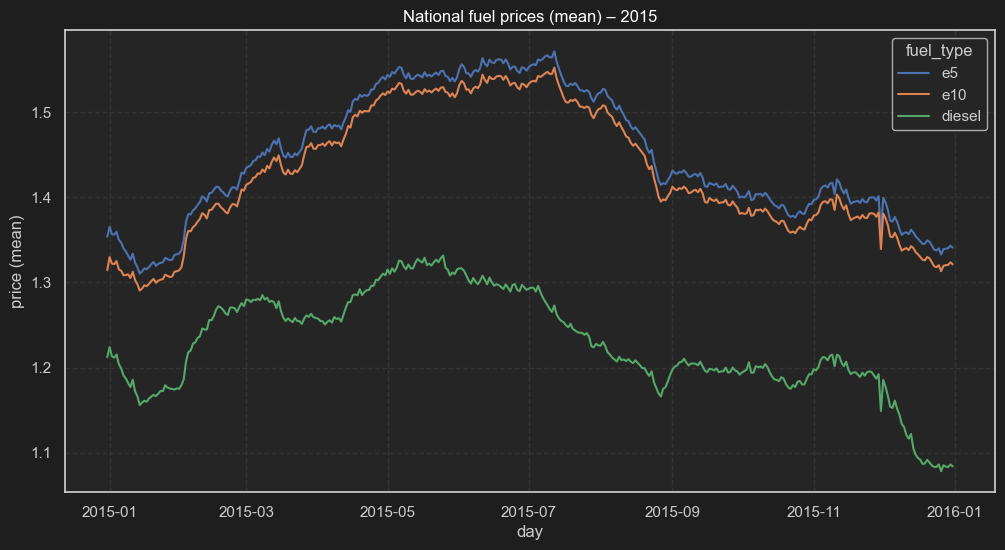

In [3]:
plot_national_fuel_prices_year(2025, stat="mean")
plot_national_fuel_prices_year(2015, stat="mean")

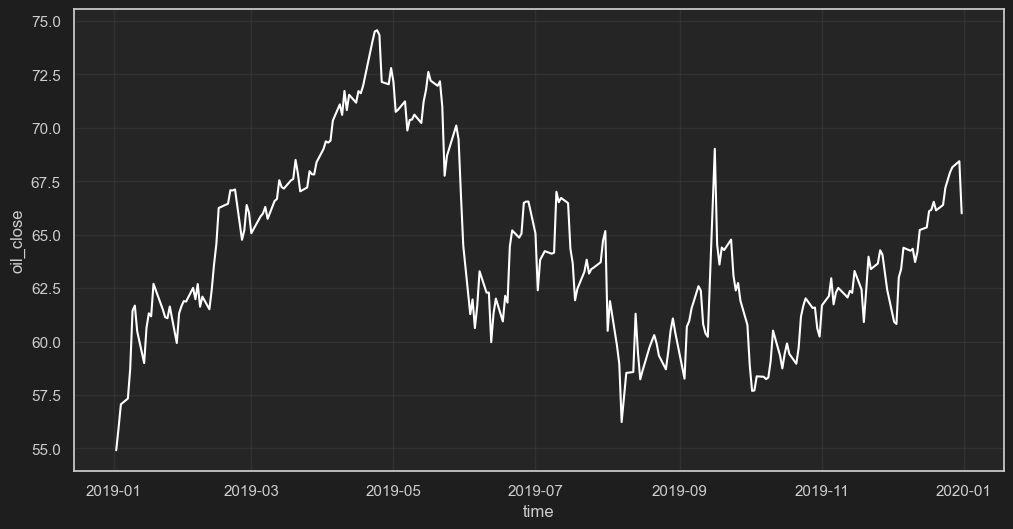

In [4]:
#--------------------------------------------------------
year = 2019 # change to which year you want to analyze
#--------------------------------------------------------

oil_d = load_brent(f"{year}-01-01", f"{year+1}-01-01", interval="1d")
oil_d.head()

plt.figure(figsize=(12, 6))
sns.lineplot(data=oil_d, x="time", y="oil_close", color="white")
plt.show()

fuel_path_d = Path(f"D:/data/derived/national_daily_last/national_daily_last_{year}.csv")
fuel_d = pd.read_csv(fuel_path_d)

oil_d["day"] = pd.to_datetime(oil_d["time"]).dt.normalize()
oil_d = oil_d[["day", "oil_close"]]

fuel_d["day"] = pd.to_datetime(fuel_d["day"]).dt.date
oil_d["day"] = pd.to_datetime(oil_d["day"]).dt.tz_localize(None).dt.date


### Merging oil and fuel, calculating Cross-Correlation-Function + 95% Confidence interval to check which lag is significant

In [5]:
#--------------------------------------------------------------------
fuel_type = "e5_mean_last" # change this to fuel type of interest
K_LAG = 50 # set maximum number of lags for CCF
#--------------------------------------------------------------------

fuel_d_small = fuel_d[["day", f"{fuel_type}"]]

# merge of fuel and oil dataframes and forward-fill oil prices to align with fuel data, then drop any remaining NaNs
merged_fill = fuel_d_small.merge(oil_d, on="day", how="left").sort_values("day")
merged_fill["oil_close"] = merged_fill["oil_close"].ffill()
merged_fill = merged_fill.dropna(subset=["oil_close", f"{fuel_type}"]).reset_index(drop=True)

merged_fill.head(10)

,day,e5_mean_last,oil_close
0,2019-01-02,1.351648,54.910000
1,2019-01-03,1.349234,55.950001
2,2019-01-04,1.350806,57.060001
3,2019-01-05,1.354252,57.060001
4,2019-01-06,1.355928,57.060001
5,2019-01-07,1.354641,57.330002
6,2019-01-08,1.350683,58.720001
7,2019-01-09,1.347230,61.439999
8,2019-01-10,1.346182,61.680000
9,2019-01-11,1.347949,60.480000


### Using
Log-Return:
$$r_t = \log(P_t) - \log(P_{t-1}) = \log\left(\frac{P_t}{P_{t-1}}\right)$$
therefore we get approximate %-change (for smaller changes):
$$r_t \approx \frac{P_t - P_{t-1}}{P_{t-1}}$$
thus the process is now $\approx$ stationary.
Now you can use the Cross-Correlation-Function (CCF):
$$\text{corr}(r_t^{fuel}, r_{t-k}^{oil})$$
### Significance of Cross-Correlations
To determine whether a correlation is statistically significant we use an approximate **95\% confidence interval**.  
A lag $k$ is considered statistically significant if
$$
|\hat{\rho}_k| > \frac{1.96}{\sqrt{N}}
$$
In the CCF plot these thresholds appear as horizontal dashed lines.  
Any lag outside this band indicates a statistically significant relationship
between oil price changes and fuel price changes.

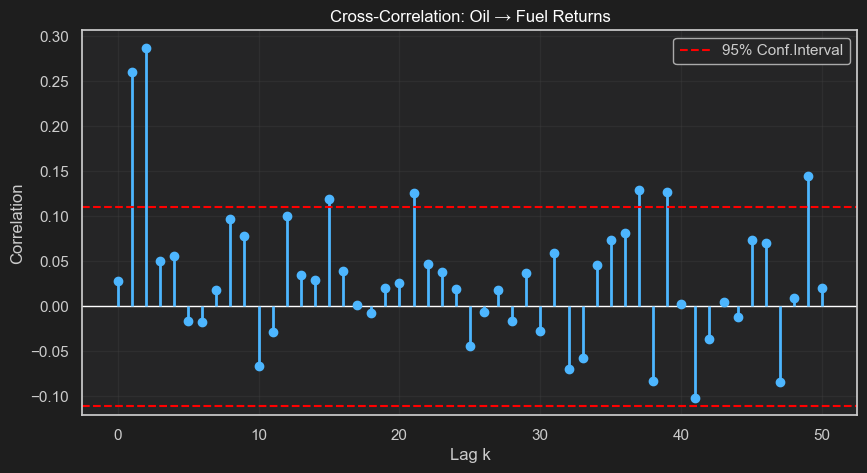

In [6]:
df_corr = merged_fill.copy()

df_corr["r_fuel"] = np.log(df_corr[f"{fuel_type}"]).diff()
df_corr["r_oil"] = np.log(df_corr["oil_close"]).diff()
df_corr = df_corr.dropna(subset=["r_fuel", "r_oil"]).reset_index(drop=True) # delete first row due to diff and potential other NaNs

# use vectorized approach to create lagged columns for r_oil (AND better performance):
lags = pd.concat([df_corr["r_oil"].shift(k) for k in range(K_LAG + 1)], axis=1)
lags.columns = [f"r_oil_lag{k}" for k in range(K_LAG + 1)]
df_corr = pd.concat([df_corr, lags], axis=1)

lag_cols = lags.columns
data_corr = df_corr.dropna(subset=list(lag_cols) + ["r_fuel"])

# compute CCF
corr_values = data_corr[lag_cols].corrwith(data_corr["r_fuel"])
ccf_df = pd.DataFrame({
    "lag_days": np.arange(K_LAG + 1),
    "corr": corr_values.to_numpy()
})

# plot CCF with confidence intervals
N = len(data_corr)
conf = 1.96 / np.sqrt(N)  # 95% confidence interval for correlation (for larger samples)

lags = ccf_df["lag_days"]
corr = ccf_df["corr"]

plt.figure(figsize=(10,5))
plt.axhline(0, color="white", linewidth=1)
plt.vlines(lags, 0, corr, color="#4db6ff", linewidth=2)
plt.scatter(lags, corr, color="#4db6ff", zorder=3)
plt.axhline(conf, color="red", linestyle="--", label="95% Conf.Interval") # confidence interval
plt.axhline(-conf, color="red", linestyle="--")
plt.xlabel("Lag k")
plt.ylabel("Correlation")
plt.title("Cross-Correlation: Oil → Fuel Returns")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Result of yearwise analysis
The CCF is different for every year, nevertheless it is possible to conclude, by looking at every year  
individually, that the **1st, 2nd and 3rd lag** are the most signifikant ones  
## =========================================
# NOW: Aggregaded data from 2014 to 2026:
### Using Matrix with **years** as rows and **lag** as columns

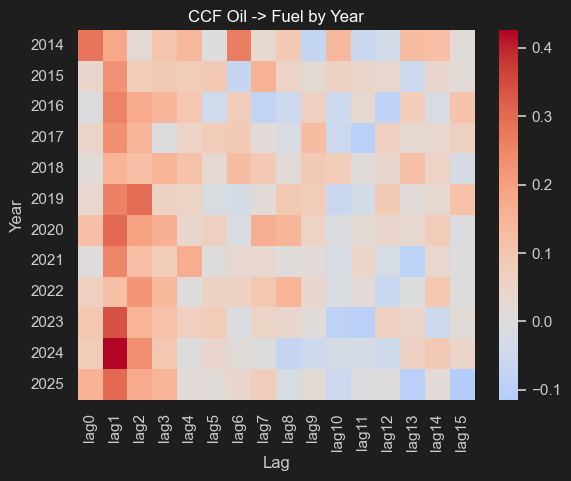

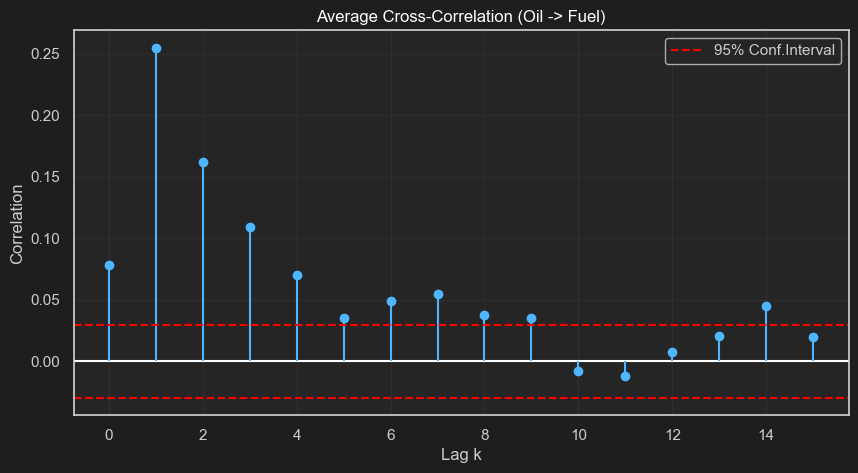

In [7]:
years = range(2014, 2026)

ccf_all = []
for y in years:
    corr = compute_ccf_year(y, fuel_type="e5_mean_last", K_LAG=15)
    ccf_all.append(corr)

ccf_all = pd.DataFrame(ccf_all)
ccf_all.index = years
mean_ccf = ccf_all.mean()

# Plot heatmap of CCFs by year
sns.heatmap(ccf_all,cmap="coolwarm",center=0)
plt.xlabel("Lag")
plt.ylabel("Year")
plt.title("CCF Oil -> Fuel by Year")

# Plot average CCF across years with confidence intervals
lags = np.arange(len(mean_ccf))
N = 365 * len(years)
conf = 1.96 / np.sqrt(N)

plt.figure(figsize=(10,5))
plt.axhline(0,color="white")
plt.vlines(lags,0,mean_ccf,color="#4db6ff")
plt.scatter(lags,mean_ccf,color="#4db6ff")
plt.axhline(conf,color="red",linestyle="--", label="95% Conf.Interval")
plt.axhline(-conf,color="red",linestyle="--")
plt.xlabel("Lag k")
plt.ylabel("Correlation")
plt.title("Average Cross-Correlation (Oil -> Fuel)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
df_all = build_panel_dataset(years, fuel_type=fuel_type)

df_all.tail()

,day,fuel_price,oil_close,year
4198,2025-12-27,1.705918,60.639999,2025
4199,2025-12-28,1.709518,60.639999,2025
4200,2025-12-29,1.708166,61.939999,2025
4201,2025-12-30,1.722879,61.919998,2025
4202,2025-12-31,1.730766,60.849998,2025
